# UMAP + HDBSCAN Clustering for RBD sequences (Omicron only), MSA
---
For a baseline comparison to ESM embedded sequences, we will use multiple sequence alignment, and then use one hot to get a numerical representation. Then use UMAP/tSNE+HDBSCAN just like in the ESM embedded sequence clustering.

In [ ]:
from sklearn.model_selection import ParameterGrid

perplexity_list = [30, 50, 100, 250, 500, 600, 650, 700, 750, 800, 900, 1000]

umap_grid = {
    "n_neighbors": [10, 15, 30, 50, 75, 100],
    "min_dist": [0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
}
umap_param_list = list(ParameterGrid(umap_grid))
print(umap_param_list)

random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8]
for rnd_seed in random_seeds:
    for umap_params in umap_param_list:
        parquet_file = os.path.join(parquet_dir, version_dir, f"RBD.ADO.MSA_one_hot-embedded.sampled_seed{rnd_seed}.umap-nneighbors{umap_params["n_neighbors"]}_mindist{umap_params["min_dist"]}.parquet")
        parquet_df = pd.read_parquet(parquet_file, engine='fastparquet')
        merged_df = parquet_df.merge(embedded_ado_df[["Seq ID", "Variant", "Pango lineage", "Location", "Collection date"]], on=["Seq ID", "Variant", "Pango lineage"], how="left")
        # print(len(merged_df))
        # display(merged_df)
        merged_df.to_parquet(parquet_file, index=False)
    

In [ ]:
parquet_file = os.path.join(parquet_dir, version_dir, f"RBD.ADO.MSA_one_hot-embedded.sampled_seed0.umap-nneighbors10_mindist0.0.parquet")
parquet_df = pd.read_parquet(parquet_file, engine='fastparquet')
display(parquet_df)

In [436]:
version_dir = "rbd_o_msa"
version_prefix = "RBD.O.MSA_one_hot-embedded"

We load in the parquet used for RBD ADO MSA, `RBD.ADO.MSA_one_hot-embedded.parquet`. This contains all of the sequences. Then we just drop everything that is not an Omicron variant.

In [418]:
import os
import pandas as pd

parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"

parquet_file = os.path.join(parquet_dir, "rbd_ado_msa", "RBD.ADO.MSA_one_hot-embedded.parquet")
embedded_ado_df = pd.read_parquet(parquet_file, engine='fastparquet')
embedded_o_df = embedded_ado_df[embedded_ado_df["variant"] == "Omicron"]

print(len(embedded_ado_df))
print(len(embedded_o_df))

291539
160016


In [419]:
embedded_o_df

,seq_id,seq,variant,pango lineage,embedding
0,EPI_ISL_16604644,RVQ--PTESIVRFPN-ITNLCP-------------FDEV-FNAT--...,Omicron,DY.1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
1,EPI_ISL_14904955,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.5,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
2,EPI_ISL_14904971,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.6,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
3,EPI_ISL_14906096,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.1.10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
4,EPI_ISL_14906040,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.2.9,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
...,...,...,...,...,...
291533,EPI_ISL_12083634,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.1.15.1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
291534,EPI_ISL_9835815,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
291536,EPI_ISL_17304059,RVQ--PTESIVRFPN-ITNLCP-------------FHEV-FNAT--...,Omicron,XBB.6,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
291537,EPI_ISL_17690414,RVQ--PTESIVRFPN-ITNLCP-------------FDEV-FNAT--...,Omicron,BA.2.9,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


In [5]:
embedded_o_df.to_parquet(os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet"), index=False)
display(embedded_o_df)

,seq_id,seq,variant,pango lineage,embedding
0,EPI_ISL_16604644,RVQ--PTESIVRFPN-ITNLCP-------------FDEV-FNAT--...,Omicron,DY.1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
1,EPI_ISL_14904955,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.5,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
2,EPI_ISL_14904971,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.6,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
3,EPI_ISL_14906096,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.1.10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
4,EPI_ISL_14906040,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.5.2.9,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
...,...,...,...,...,...
291533,EPI_ISL_12083634,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.1.15.1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
291534,EPI_ISL_9835815,RVQ--PTESIVRFPNI-TNLCP-------------FDEVF-NAT--...,Omicron,BA.1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
291536,EPI_ISL_17304059,RVQ--PTESIVRFPN-ITNLCP-------------FHEV-FNAT--...,Omicron,XBB.6,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
291537,EPI_ISL_17690414,RVQ--PTESIVRFPN-ITNLCP-------------FDEV-FNAT--...,Omicron,BA.2.9,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


---
## UMAP Parameter Sweep
(doc: https://docs.rapids.ai/api/cuml/stable/api/generated/cuml.manifold.umap/#cuml.manifold.UMAP)

Some more on parameters for UMAP:
- https://umap-learn.readthedocs.io/en/latest/parameters.html
- https://pair-code.github.io/understanding-umap/

We adjust our parameter sweep to include noise fraction. This is the proportion of points that HDBSCAN labels as noise/outliers, meaning they are not assigned to any cluster.

For example: If you have 100 sequences and HDBSCAN labels:
- 80 into clusters
- 20 as -1
- Then: noise_fraction = 20 / 100 = 0.20. This results in a noise_fraction of 0.2, or 20% of the data!

Why does it matter?
| Noise fraction | Interpretation                                  |
| -------------- | ----------------------------------------------- |
| Low            | most points were assigned to clusters           |
| Moderate       | HDBSCAN is being selective                      |
| High           | many points do not fit well into dense clusters |

This will allow us to better make sense of our ARI scores. Some scenarios to help make better sense:
| ARI  | Noise fraction | Interpretation                             |
| ---- | -------------- | ------------------------------------------ |
| High | Low            | Strong result                              |
| High | Very high      | Maybe only a subset clustered well         |
| Low  | High           | Clustering may be too strict               |
| Low  | Low            | Clustering may be forcing poor assignments |

And a more specific example:
| Setting | ARI  | Noise fraction |
| ------- | ---- | -------------- |
| A       | 0.82 | 0.08           |
| B       | 0.83 | 0.47           |

I would usually trust A more, because B is discarding almost half the dataset. Note this is just an additional option that we can use to help determine a plot to use.

In [6]:
import os
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import cupy as cp
from cuml.manifold import UMAP
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def umap_hdbscan_parameter_sweep(parquet_file, embedded_df, n_neighbors_list, min_dist_list, min_samples_list, min_cluster_size_list):
    umap_grid = {
        "n_neighbors": n_neighbors_list,
        "min_dist": min_dist_list,
    }
    umap_param_list = list(ParameterGrid(umap_grid))

    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    # CPU -> GPU
    embedding_matrix = np.vstack(embedded_df["embedding"].values).astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)
    y_true = LabelEncoder().fit_transform(embedded_df["variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # Parameter Sweep (UMAP)
    for umap_params in tqdm(umap_param_list, desc="UMAP sweep"):
        reducer = UMAP(
            n_neighbors=umap_params["n_neighbors"],
            min_dist=umap_params["min_dist"],
            metric="cosine",
            random_state=42,
        )
        X_red = reducer.fit_transform(X_gpu)
        X_red_cpu = cp.asnumpy(X_red)

        umap_df = pd.DataFrame({
            'UMAP 1': X_red_cpu[:, 0],
            'UMAP 2': X_red_cpu[:, 1],
            'Seq ID': embedded_df['seq_id'].values,
            'Variant': embedded_df['variant'].values,
            'Pango lineage': embedded_df['pango lineage'].values,
        })
        save_as = parquet_file.replace(".parquet", f".umap-nneighbors{umap_params["n_neighbors"]}_mindist{umap_params["min_dist"]}.parquet")
        umap_df.to_parquet(save_as, engine='fastparquet')

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(hdbscan_param_list, leave=False):
            clusterer = HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
            )

            labels = clusterer.fit_predict(X_red)
            ari = float(adjusted_rand_score(y_true_gpu, labels))
            noise_fraction = float(cp.mean(labels == -1))

            non_noise_mask = labels != -1
            valid_cluster_labels = labels[non_noise_mask]
            
            n_non_noise_samples = int(cp.sum(non_noise_mask))
            n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

            # silhouette needs at least two clusters AND
            # avoids the case where every non-noise point is its own cluster
            if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
                silhouette_avg = float(silhouette_score(X_red[non_noise_mask], valid_cluster_labels,  metric="cosine"))
            else:
                silhouette_avg = np.nan            

            all_results.append({
                "n_neighbors": umap_params["n_neighbors"],
                "min_dist": umap_params["min_dist"],
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": noise_fraction,
                "silhouette": silhouette_avg,
                "n_clusters": n_non_noise_clusters,
            })
            
        # cleanup
        del X_red
        cp._default_memory_pool.free_all_blocks()

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
%%time

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"

umap_grid = {
    "n_neighbors": [10, 15, 30, 50, 75, 100],
    "min_dist": [0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
}

hdbscan_grid = {
    "min_samples": [10, 25, 50, 100, 250, 500, 1000], # cuml HDBSCAN blocks min_samples above 1023
    "min_cluster_size": [50, 100, 250, 500, 1000, 2500, 5000, 10000, 15000, 20000, 22000],
}

parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet")
embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")

full_results_umap_df = umap_hdbscan_parameter_sweep(
    parquet_file,
    embedded_df, 
    umap_grid["n_neighbors"],
    umap_grid["min_dist"],
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_umap_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"), index=False)

UMAP sweep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [4:02:14<00:00, 346.05s/it]

CPU times: user 3h 46min 47s, sys: 14min 27s, total: 4h 1min 14s
Wall time: 4h 4min 11s


---
## TSNE Parameter Sweep
(doc: https://docs.rapids.ai/api/cuml/stable/api/generated/cuml.manifold.tsne/#cuml.manifold.TSNE)

NOTE: We don't use this in the paper. The one in the paper is located in the folder `rbd_ado`. This was just an experiment to test cuml TSNE.

Suggestion of using:
```python
    n_samples = X_gpu.shape[0]
    early_exaggeration = 24.0 if n_samples > 10000 else 12.0 # Default 12.0
    learning_rate = max(n_samples / early_exaggeration, 200) # Default: 200
```
Comes from:
- https://github.com/rapidsai/cuml/issues/2375
- https://www.nature.com/articles/s41467-019-13055-y

More by them:
- https://www.nature.com/articles/s41467-019-13056-x
- https://www.biorxiv.org/content/10.1101/2019.12.19.877522v1

We adjust our parameter sweep to include noise fraction. This is the proportion of points that HDBSCAN labels as noise/outliers, meaning they are not assigned to any cluster.

For example: If you have 100 sequences and HDBSCAN labels:
- 80 into clusters
- 20 as -1
- Then: noise_fraction = 20 / 100 = 0.20. This results in a noise_fraction of 0.2, or 20% of the data!

Why does it matter?
| Noise fraction | Interpretation                                  |
| -------------- | ----------------------------------------------- |
| Low            | most points were assigned to clusters           |
| Moderate       | HDBSCAN is being selective                      |
| High           | many points do not fit well into dense clusters |

This will allow us to better make sense of our ARI scores. Some scenarios to help make better sense:
| ARI  | Noise fraction | Interpretation                             |
| ---- | -------------- | ------------------------------------------ |
| High | Low            | Strong result                              |
| High | Very high      | Maybe only a subset clustered well         |
| Low  | High           | Clustering may be too strict               |
| Low  | Low            | Clustering may be forcing poor assignments |

And a more specific example:
| Setting | ARI  | Noise fraction |
| ------- | ---- | -------------- |
| A       | 0.82 | 0.08           |
| B       | 0.83 | 0.47           |

I would usually trust A more, because B is discarding almost half the dataset. Note this is just an additional option that we can use to help determine a plot to use.

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import cupy as cp
from cuml.manifold import TSNE
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def tsne_hdbscan_parameter_sweep(parquet_file, embedded_df, perplexity_list, min_samples_list, min_cluster_size_list):
    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    # CPU -> GPU
    embedding_matrix = np.vstack(embedded_df["embedding"].values).astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)
    y_true = LabelEncoder().fit_transform(embedded_df["variant"].values)
    y_true_gpu = cp.asarray(y_true)

    n_samples = X_gpu.shape[0]
    early_exaggeration = 24.0 if n_samples > 10000 else 12.0 # Default 12.0
    learning_rate = max(n_samples / early_exaggeration, 200) # Default: 200

    # Parameter Sweep (TSNE)
    for perp in tqdm(perplexity_list, desc="TSNE sweep"):
        save_as = parquet_file.replace(".parquet", f".tsne-perplexity{perp}.parquet")

        if os.path.exists(save_as):
            print(f"Found existing t-SNE file, loading: {save_as}")
            tsne_df = pd.read_parquet(save_as, engine="fastparquet")

            X_red_cpu = tsne_df[["t-SNE component 1", "t-SNE component 2"]].values.astype(np.float32)
            X_red = cp.asarray(X_red_cpu)

        else:
            reducer = TSNE(
                n_components=2,
                perplexity=perp,
                n_neighbors=3 * perp,   # recommended by cuml, caps at 1023
                init="pca",             # like openTSNE
                metric="cosine",
                method="fft",
                random_state=42,
                early_exaggeration=early_exaggeration,
                learning_rate=learning_rate,
                learning_rate_method=None,
            )
            X_red = reducer.fit_transform(X_gpu)
            X_red_cpu = cp.asnumpy(X_red)

            # Save 
            tsne_df = pd.DataFrame({
                't-SNE component 1': X_red_cpu[:, 0],
                't-SNE component 2': X_red_cpu[:, 1],
                'Seq ID': embedded_df['seq_id'].values,
                'Variant': embedded_df['variant'].values,
                'Pango lineage': embedded_df['pango lineage'].values,
                'Collection date': embedded_df['Collection date'],
            })
            
            tsne_df.to_parquet(save_as, engine='fastparquet')

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(hdbscan_param_list, leave=False):
            clusterer = HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
            )

            labels = clusterer.fit_predict(X_red)
            ari = float(adjusted_rand_score(y_true_gpu, labels))
            noise_fraction = float(cp.mean(labels == -1))

            non_noise_mask = labels != -1
            valid_cluster_labels = labels[non_noise_mask]
            
            n_non_noise_samples = int(cp.sum(non_noise_mask))
            n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

            # silhouette needs at least two clusters AND
            # avoids the case where every non-noise point is its own cluster
            if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
                silhouette_avg = float(silhouette_score(X_red[non_noise_mask], valid_cluster_labels,  metric="cosine"))
            else:
                silhouette_avg = np.nan                

            all_results.append({
                "perplexity": perp,
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": noise_fraction,
                "silhouette": silhouette_avg,
                "n_clusters": n_non_noise_clusters,
            })
            
        # cleanup
        del X_red
        cp._default_memory_pool.free_all_blocks()

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

In [9]:
%%time

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"

perplexity_list = [30, 50, 100, 250, 500, 600, 650, 700, 750, 800, 900, 1000]

hdbscan_grid = {
    "min_samples": [10, 25, 50, 100, 250, 500, 1000], # cuml HDBSCAN blocks min_samples above 1023
    "min_cluster_size": [50, 100, 250, 500, 1000, 2500, 5000, 10000, 15000, 20000, 22000],
}

parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet")
embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")

full_results_tsne_df = tsne_hdbscan_parameter_sweep(
    parquet_file,
    embedded_df, 
    perplexity_list,
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_tsne_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-tsne_hdbscan-parameter_sweep.csv"), index=False)

TSNE sweep:  17%|██████████████████████████████████████████████████████                                                                                                                                                                                                                                                                              | 2/12 [06:44<33:38, 201.88s/it]

[2026-04-28 07:13:45.872] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...


TSNE sweep:  25%|█████████████████████████████████████████████████████████████████████████████████                                                                                                                                                                                                                                                   | 3/12 [10:13<30:46, 205.15s/it]

[2026-04-28 07:17:14.916] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...


TSNE sweep:  33%|████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                                                                                        | 4/12 [15:14<32:22, 242.76s/it]/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/cuml/internals/outputs.py:424: UserWarning: n_neighbors (1500) should be < 1024, thresholding n_neighbors to 1023
  res = func(*args, **kwargs)


...

[2026-04-28 07:59:50.321] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-04-28 07:59:50.321] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


TSNE sweep:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                           | 11/12 [59:12<06:10, 370.78s/it]/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/cuml/internals/outputs.py:424: UserWarning: n_neighbors (3000) should be < 1024, thresholding n_neighbors to 1023
  res = func(*args, **kwargs)


[2026-04-28 08:06:14.008] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-04-28 08:06:14.008] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


TSNE sweep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [1:05:41<00:00, 328.45s/it]

CPU times: user 1h 3min 28s, sys: 5min 10s, total: 1h 8min 39s
Wall time: 1h 9min 20s


---
## Plotting

Let's take a look at several n_neighbors and min_dist options:

In [420]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_umap_grid(parquet_dir, version_dir, version_prefix, n_neighbors_list, min_dist_list):
    n_rows = len(n_neighbors_list)
    n_cols = len(min_dist_list)

    sns.set_style("ticks")
    sns.set_context("talk")

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows),
        squeeze=False
    )

    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for i, n_neighbors in enumerate(n_neighbors_list):
        for j, min_dist in enumerate(min_dist_list):
            ax = axes[i, j]

            parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")
            plot_df = pd.read_parquet(parquet_file, engine="fastparquet")

            unique_variants = np.unique(plot_df["Variant"])
            variant_color_palette = sns.color_palette("tab10", n_colors=len(unique_variants))
            variant_color_dict = {
                label: color for label, color in zip(unique_variants, variant_color_palette)
            }
            variant_colors = [variant_color_dict[v] for v in plot_df["Variant"]]

            ax.scatter(
                plot_df["UMAP 1"],
                plot_df["UMAP 2"],
                c=variant_colors,
                s=25,
                alpha=0.5,
                edgecolor="none",
                linewidth=0,
            )

            ax.set_xticks([])
            ax.set_yticks([])

            # Only show y-axis label on first column
            if j == 0:
                ax.set_ylabel(f"n_neighbors={n_neighbors}")

            # Only show x-axis label on bottom row
            if i == n_rows - 1:
                ax.set_xlabel(f"min_dist={min_dist}")

    # One shared legend
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=variant_color_dict[v],
            markersize=8,
        )
        for v in unique_variants
    ]

    fig.legend(
        handles,
        unique_variants,
        loc="lower center",
        ncol=len(unique_variants),
        frameon=False,
        bbox_to_anchor=(0.5, 0.075),
    )

    plt.show()

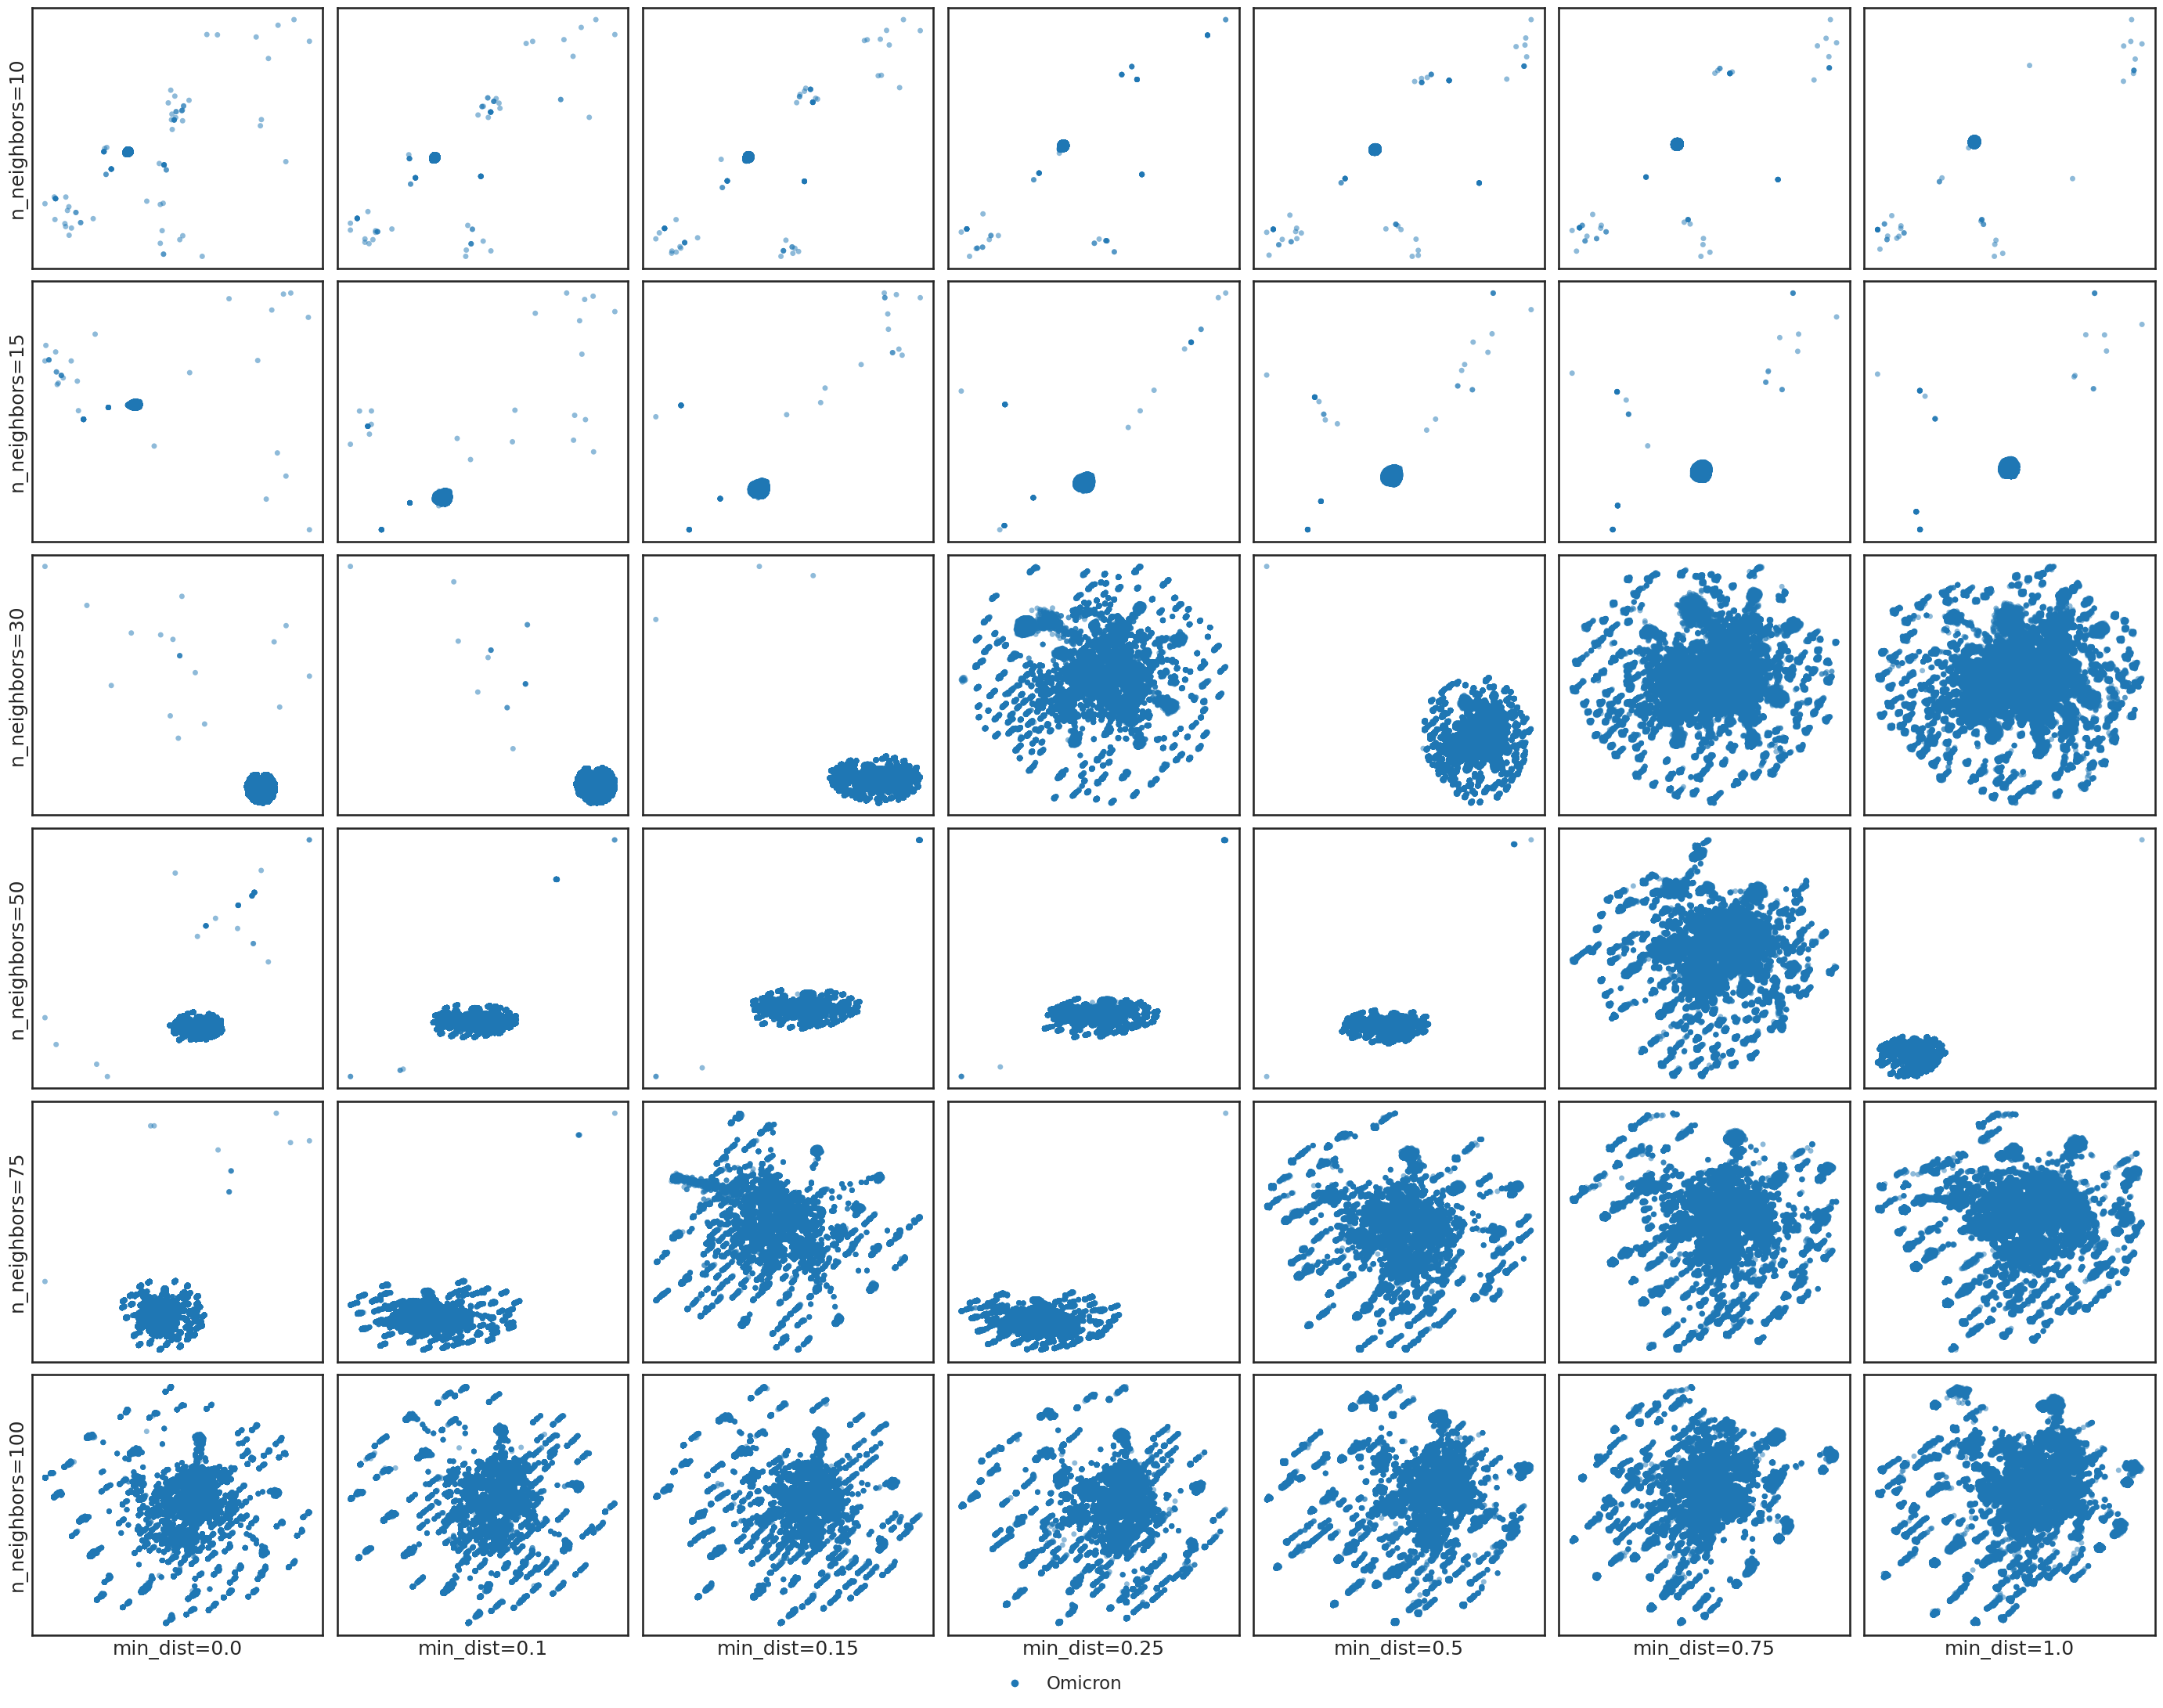

In [421]:
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"

plot_umap_grid(
    parquet_dir,
    version_dir,
    version_prefix,
    n_neighbors_list=[10, 15, 30, 50, 75, 100],
    min_dist_list=[0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
)

In [445]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import cupy as cp
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def get_coord_cols(df):
    if {"t-SNE component 1", "t-SNE component 2"}.issubset(df.columns):
        return "t-SNE component 1", "t-SNE component 2", "t-SNE"
    elif {"UMAP 1", "UMAP 2"}.issubset(df.columns):
        return "UMAP 1", "UMAP 2", "UMAP"
    else:
        raise ValueError("Could not find t-SNE or UMAP coordinate columns.")

def get_hdbscan_values(parquet_file, min_samples, min_cluster_size):
    embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")
    x_col, y_col, method_name = get_coord_cols(embedded_df)
    
    # CPU -> GPU
    embedding_matrix = embedded_df[[x_col, y_col]].values.astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)

    y_true = LabelEncoder().fit_transform(embedded_df["Variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # GPU HDBSCAN
    clusterer = HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
    )

    labels_gpu = clusterer.fit_predict(X_gpu)

    # GPU metrics
    ari = float(adjusted_rand_score(y_true_gpu, labels_gpu))
    noise_fraction = float(cp.mean(labels_gpu == -1))

    non_noise_mask = labels_gpu != -1
    valid_cluster_labels = labels_gpu[non_noise_mask]

    n_non_noise_samples = int(cp.sum(non_noise_mask))
    n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

    # silhouette needs at least two clusters AND
    # avoids the case where every non-noise point is its own cluster
    if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
        silhouette_avg = float(silhouette_score(X_gpu[non_noise_mask], valid_cluster_labels,  metric="cosine"))
    else:
        silhouette_avg = np.nan                

    print(
        f"min_samples = {min_samples}, "
        f"min_cluster_size = {min_cluster_size}: "
        f"ARI = {ari:.2f}, "
        f"Silhouette = {silhouette_avg:.2f}, "
        f"Clusters = {n_non_noise_clusters}, "
        f"Noise = {noise_fraction:.2%}"
    )

    # GPU -> CPU for pandas
    labels = cp.asnumpy(labels_gpu)

    truth_table_percent = pd.crosstab(
        embedded_df["Variant"],
        labels,
        rownames=["Ground Truth"],
        colnames=["Predicted Clusters"],
        normalize="index",
    )
    truth_table_percent = (truth_table_percent * 100).round(2)

    plot_df = pd.DataFrame({
        x_col: embedded_df[x_col].values,
        y_col: embedded_df[y_col].values,
        "Cluster": labels,
        "Seq ID": embedded_df["Seq ID"].values,
        "Variant": embedded_df["Variant"].values,
        "Pango lineage": embedded_df["Pango lineage"].values,
    })

    save_as = parquet_file.replace(
        ".parquet",
        f".HDBSCAN-ms{min_samples}_mcs{min_cluster_size}-ari{ari:.2f}_sc{silhouette_avg:.2f}_noise{noise_fraction:.2f}"
    )
    plot_df.to_parquet(f"{save_as}.parquet", engine="fastparquet", index=False)

    del X_gpu, labels_gpu
    cp.get_default_memory_pool().free_all_blocks()

    return plot_df, truth_table_percent, save_as

def plot_groundtruth_prediction_1x2(plot_df, save_as, plot_dir, x_min_width_buffer, x_max_width_buffer, y_min_width_buffer, y_max_width_buffer, color_map, cluster_color_palette_order=None):
    marker_size = 25
    
    # Define a variant color palette
    unique_variants = np.unique(plot_df['Variant'])
    variant_color_palette = sns.color_palette(color_map, n_colors=len(unique_variants)) 
    variant_color_dict = {label: color for label, color in zip(unique_variants, variant_color_palette)}

    # Define a cluster color palette
    unique_clusters = np.unique(plot_df["Cluster"])
    non_noise_clusters = unique_clusters[unique_clusters != -1]

    cluster_color_palette = sns.color_palette(color_map, n_colors=len(non_noise_clusters))

    if cluster_color_palette_order is not None:
        cluster_color_palette = sns.color_palette(color_map)
        cluster_color_palette = [cluster_color_palette[i] for i in cluster_color_palette_order]

    cluster_color_dict = {label: color for label, color in zip(non_noise_clusters, cluster_color_palette)}
    cluster_color_dict[-1] = 'black'  # Set outliers to x

    sns.set_style('ticks')
    sns.set_context("poster")
    fig, axs = plt.subplots(1, 2, figsize=(20.25, 6.5), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # Reduce the horizontal space between subplots

    x_col, y_col, method_name = get_coord_cols(plot_df)
    #####################################################

    # Scatterplot
    sns.scatterplot(
        data=plot_df,
        x=x_col, y=y_col,
        hue='Variant', palette=variant_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[0]
    )

    # axs[0].set_title(f"Ground Truth ({len(unique_variants)} variants)", ha='center', fontweight='bold')
    axs[0].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))
    axs[0].set_ylim(plot_df[y_col].min()-y_min_width_buffer, plot_df[y_col].max()+y_max_width_buffer),

    # Legend 
    variant_handles = [
        plt.Line2D([0], [0], color=variant_color_dict[variant], label=f'{variant}')
        for variant in unique_variants
    ]
    axs[0].legend(handles=variant_handles)
    sns.move_legend(axs[0], "upper right", fontsize=14)
    
    # #####################################################

    # Scatterplot for non-outliers
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] != -1],  # Exclude outliers
        x=x_col, y=y_col,
        hue='Cluster', palette=cluster_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[1]
    )

    # Scatterplot for outliers (Cluster = -1)
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] == -1],  # Select only outliers
        x=x_col, y=y_col,
        marker='x',
        s=marker_size*2, color='black', linewidth=2,
        ax=axs[1]
    )

    # axs[1].set_title(f"Predicted ({len(unique_clusters[unique_clusters != -1])} clusters)", ha='center', fontweight='bold')
    axs[1].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))

    # Legend 
    cluster_handles = [plt.Line2D([0], [0], marker='x', color='black', linestyle='none', label='Outliers')]
    cluster_handles += [
        plt.Line2D([0], [0], color=cluster_color_dict[cluster], label=f'Cluster {cluster}')
        for cluster in unique_clusters if cluster != -1
    ]
    axs[1].legend(handles=cluster_handles)
    sns.move_legend(axs[1], "upper right", fontsize=14)

    #####################################################
    base = os.path.splitext(os.path.basename(save_as))[0]  
    filename = f"{base}"
    
    save_as = os.path.join(plot_dir, filename)  
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')
    plt.show()

In [426]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def ari_sc_heatmap(results_df, save_as, plot_dir):

    # Convert to DataFrame
    df = results_df.copy()

    # Pivot matrices
    ari_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='ari')
    silhouette_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='silhouette')

    # Plot heatmaps
    sns.set_style('ticks')
    sns.set_context("talk")
    fig, axs = plt.subplots(2, 1, figsize=(20, 20))

    sns.heatmap(ari_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[0], vmin=-0.19, vmax=1)
    axs[0].set_title("Adjusted Rand Index (ARI)")
    axs[0].set_xlabel("min_cluster_size")
    axs[0].set_ylabel("min_samples")

    max_ari = ari_matrix.max().max()  # Get the max ARI value

    for i in range(ari_matrix.shape[0]):  # min_sample (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[0].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    sns.heatmap(silhouette_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[1], vmin=-0.19, vmax=1)
    axs[1].set_title("Silhouette Coefficient")
    axs[1].set_xlabel("min_cluster_size")
    axs[1].set_ylabel("min_samples")

    for i in range(ari_matrix.shape[0]):  # min_samples (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[1].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    base = os.path.splitext(os.path.basename(parquet_file))[0]
    filename = f"{base}.HDBSCAN_heatmap"
    
    save_as = os.path.join(plot_dir, filename)
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')

    plt.show()

In [441]:
import os
import pandas as pd

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/param_sweeps"

full_results_umap_df = pd.read_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"))
scored_results_df = full_results_umap_df.copy()

In [442]:
# Make sure ari between -1 and 1...
invalid_ari_mask = (
    scored_results_df["ari"].notna()
    & ~scored_results_df["ari"].between(-1, 1)
)

print("Invalid ari rows:", invalid_ari_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_ari_mask].copy()

print("Rows after:", len(scored_results_df))

# Make sure silhouette between -1 and 1...
invalid_silhouette_mask = (
    scored_results_df["silhouette"].notna()
    & ~scored_results_df["silhouette"].between(-1, 1)
)

print("Invalid silhouette rows:", invalid_silhouette_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_silhouette_mask].copy()

print("Rows after:", len(scored_results_df))

Invalid ari rows: 0
Rows before: 3234
Rows after: 3234
Invalid silhouette rows: 24
Rows before: 3234
Rows after: 3210


### Best result within each UMAP setting, based on just SC

In [446]:
summary_df = (
    scored_results_df
    .sort_values(by=["silhouette"], ascending=[False])
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print(f"Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df.sort_values(
        by=["best_silhouette"],
        ascending=[False]
    ).head(5)
).reset_index(drop=True)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,15,0.50,1000,5000,0.000000e+00,0.740513,0.882598,4
1,15,0.15,1000,5000,-2.960353e-16,0.689600,0.851991,5
2,15,0.00,1000,10000,0.000000e+00,0.797314,0.849174,2
3,15,0.10,500,5000,0.000000e+00,0.775066,0.843595,4
4,30,0.75,1000,250,0.000000e+00,0.321980,0.838191,22


Seed 0 | UMAP | n_neighbors = 15, min_dist = 0.5
min_samples = 1000, min_cluster_size = 5000: ARI = 0.00, Silhouette = 0.88, Clusters = 4, Noise = 74.05%
4: [0 1 2 3]


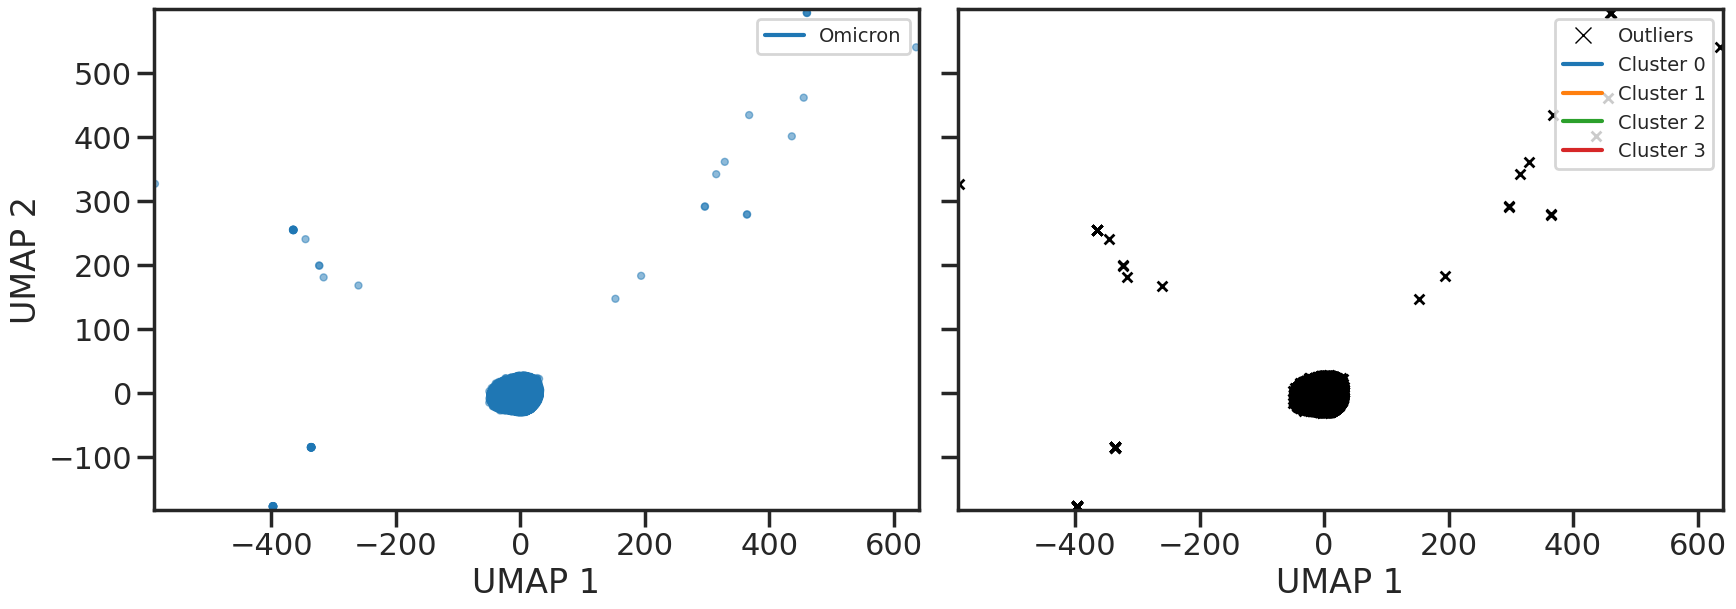

Predicted Clusters,-1,0,1,2,3
Ground Truth,,,,,
Omicron,74.05,5.41,4.48,9.62,6.44


In [447]:
rnd_seed = 0 # ONLY refers to the data, not the UMAP or TSNE random state

best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"Seed 0 | UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    plot_dir=os.path.join(plot_dir, version_dir),
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab10", 
    cluster_color_palette_order=[0, 1, 2, 3]
)
display(truth_table_percent)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.dates as mdates

def cluster_date_collected(plot_df, save_as, colormap):
    """ Calculate variant percentages over collection dates within clusters and plot them in a single plot. """
    
    # Copy the DataFrame to avoid modifying the original
    df = plot_df.copy()

    # Define cluster color mapping, with outliers (Cluster -1) as black
    unique_clusters = np.unique(df['Cluster'])
    cluster_colors = sns.color_palette(colormap, n_colors=len(unique_clusters)-1)  # -1 to exclude outliers
    if len(sns.color_palette(colormap)) < (len(unique_clusters)-1):
        cluster_colors = sns.color_palette(colormap) + sns.color_palette(["#999933", "#882255", "#661100", "#6699CC", "#332288"])
    cluster_color_dict = {label: color for label, color in zip(unique_clusters[unique_clusters != -1], cluster_colors)}
    cluster_color_dict[-1] = 'black'  # Outliers are gray

    # Ensure 'Collection date' is a datetime object
    df['Collection date'] = pd.to_datetime(df['Collection date'], format='mixed')

    # Aggregate data by counting variants for each collection date (by year and month)
    df['YearMonth'] = df['Collection date'].dt.to_period('M')
    cluster_date_counts = df.groupby(['Cluster', 'YearMonth', 'Variant']).size().reset_index(name='Cluster count')

    # Calculate total count within each cluster
    total_cluster_count = df.groupby(['Cluster']).size().reset_index(name='Total count')
    cluster_date_counts = cluster_date_counts.merge(total_cluster_count, on='Cluster')

    # Calculate percentages within each cluster
    cluster_date_counts['Cluster %'] = (cluster_date_counts['Cluster count'] / cluster_date_counts['Total count']) * 100

    # Sort by 'Cluster' and 'YearMonth'
    cluster_date_counts = cluster_date_counts.sort_values(by=['Cluster', 'YearMonth'], ascending=[True, True])

    # Create a single plot with all clusters and variants
    sns.set_style('ticks')
    sns.set_context("poster")
    fig, ax = plt.subplots(figsize=(16, 10))

    # Plot each cluster-variant pair in the same plot, applying color mapping
    for (cluster_label, variant), grouped_df in cluster_date_counts.groupby(['Cluster', 'Variant']):
        ax.plot(grouped_df['YearMonth'].dt.to_timestamp(), 
                grouped_df['Cluster %'], 
                label=f"Cluster {cluster_label}",
                color=cluster_color_dict[cluster_label],  # Apply cluster-specific color
                linewidth=3)

    fontsize = 20
    ax.set_xlabel('Collection Date', fontsize=fontsize)
    ax.set_ylabel(f'Percentage (%)', fontsize=fontsize)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend(loc='upper right', fontsize=fontsize-6, bbox_to_anchor=(1, 1))

    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.ylim(-1, 59)
    plt.tight_layout()
    plt.savefig(save_as + ".timescale.pdf", format="pdf")
    plt.savefig(save_as + ".timescale.png", format="png")
    plt.show()

def get_hdbscan_values(parquet_file, min_samples, min_cluster_size):
    embedded_df = pd.read_parquet(parquet_file, engine='fastparquet')
    embedding_matrix = embedded_df[['t-SNE component 1', 't-SNE component 2']].values

    # Cluster
    hdb_labels = hdbscan.HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
        core_dist_n_jobs=-1  # Enable parallel processing
    ).fit(embedding_matrix).labels_

    # Evaluate clustering
    silhouette_avg = silhouette_score(embedding_matrix, hdb_labels)
    ari = adjusted_rand_score(embedded_df["Variant"], hdb_labels)
    print(f"min_sample {min_samples}, min_cluster_size {min_cluster_size}: Adjusted Rand Index: {ari:.2f}, Silhouette Coefficient: {silhouette_avg:.2f}")

    # Create the truth table
    truth_table_percent = pd.crosstab(embedded_df["Variant"], hdb_labels, 
                                    rownames=['Ground Truth'], 
                                    colnames=['Predicted Clusters'],
                                    normalize='index')  # Normalize along the index (rows)
    truth_table_percent = (truth_table_percent * 100).round(2)

    # Save
    plot_df = pd.DataFrame({
        't-SNE component 1': embedded_df['t-SNE component 1'],
        't-SNE component 2': embedded_df['t-SNE component 2'],
        'Cluster': hdb_labels,
        'Seq ID': embedded_df['Seq ID'],
        'Variant': embedded_df['Variant'],
        'Pango lineage': embedded_df['Pango lineage'],
        'Collection date': embedded_df['Collection date']
    })    
    save_as = parquet_file.replace(".parquet", f".HDBSCAN-ms{min_samples}_mcs{min_cluster_size}-ari{ari:.2f}_sc{silhouette_avg:.2f}")
    plot_df.to_parquet(f"{save_as}.parquet", engine='fastparquet')
    
    return plot_df, truth_table_percent, save_as

def plot_groundtruth_prediction_1x2(plot_df, save_as, x_min_width_buffer, x_max_width_buffer, y_min_width_buffer, y_max_width_buffer, color_map, cluster_color_palette_order):
    marker_size = 25
    
    # Define a variant color palette
    unique_variants = np.unique(plot_df['Variant'])
    variant_color_palette = sns.color_palette(color_map, n_colors=len(unique_variants)) 
    variant_color_dict = {label: color for label, color in zip(unique_variants, variant_color_palette)}

    # Define a cluster color palette
    unique_clusters = np.unique(plot_df['Cluster'])
    cluster_color_palette = sns.color_palette(color_map, n_colors=20) 
    cluster_color_palette = [cluster_color_palette[i] for i in cluster_color_palette_order]
    cluster_color_dict = {label: color for label, color in zip(unique_clusters[unique_clusters != -1], cluster_color_palette)}
    cluster_color_dict[-1] = 'black'  # Set outliers to x

    sns.set_style('ticks')
    sns.set_context("poster")
    fig, axs = plt.subplots(1, 2, figsize=(20.25, 6.5), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # Reduce the horizontal space between subplots

    #####################################################

    # Scatterplot
    sns.scatterplot(
        data=plot_df,
        x='t-SNE component 1', y='t-SNE component 2',
        hue='Variant', palette=variant_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[0]
    )

    # axs[0].set_title(f"Ground Truth ({len(unique_variants)} variants)", ha='center', fontweight='bold')
    axs[0].set_xlim((plot_df['t-SNE component 1'].min()-x_min_width_buffer, plot_df['t-SNE component 1'].max()+x_max_width_buffer))
    axs[0].set_ylim(plot_df['t-SNE component 2'].min()-y_min_width_buffer, plot_df['t-SNE component 2'].max()+y_max_width_buffer),

    # Legend 
    variant_handles = [
        plt.Line2D([0], [0], color=variant_color_dict[variant], label=f'{variant}')
        for variant in unique_variants
    ]
    axs[0].legend(handles=variant_handles)
    sns.move_legend(axs[0], "upper right", fontsize=14)
    
    # #####################################################

    # Scatterplot for non-outliers
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] != -1],  # Exclude outliers
        x='t-SNE component 1', y='t-SNE component 2',
        hue='Cluster', palette=cluster_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[1]
    )

    # Scatterplot for outliers (Cluster = -1)
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] == -1],  # Select only outliers
        x='t-SNE component 1', y='t-SNE component 2',
        marker='x',
        s=marker_size*2, color='black', linewidth=2,
        ax=axs[1]
    )

    # axs[1].set_title(f"Predicted ({len(unique_clusters[unique_clusters != -1])} clusters)", ha='center', fontweight='bold')
    axs[1].set_xlim((plot_df['t-SNE component 1'].min()-x_min_width_buffer, plot_df['t-SNE component 1'].max()+x_max_width_buffer))

    # Legend 
    cluster_handles = [plt.Line2D([0], [0], marker='x', color='black', linestyle='none', label='Outliers')]
    cluster_handles += [
        plt.Line2D([0], [0], color=cluster_color_dict[cluster], label=f'Cluster {cluster}')
        for cluster in unique_clusters if cluster != -1
    ]
    axs[1].legend(handles=cluster_handles)
    sns.move_legend(axs[1], "upper right", fontsize=14)

    #####################################################
  
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')
    plt.show()

perp = 1600
parquet_file = f"RBD.O.MSA.tSNE-perplexity{perp}.parquet"

min_samples=1000
min_cluster_size=4500
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab20", cluster_color_palette_order=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
)
cluster_date_collected(plot_df, save_as, "tab20")

truth_table_percent